In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Load the raw data
df_raw = pd.read_csv('Breast_Cancer.csv')

print("Dataset shape:", df_raw.shape)
print("\nFirst few rows:")
print(df_raw.head())
print("\nData types:")
print(df_raw.dtypes)

Dataset shape: (4024, 16)

First few rows:
   Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   
2  Moderately differentiated     2  Regional          63        Positive   
3      Poorly differentiated     3  Regional          18        Positive   
4      Poorly differentiated     3  Regional          41        Positive   

  Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0            Positive                      24                      1   
1

In [ ]:
# First, let's check the exact column names
print("Column names with their exact characters:")
for i, col in enumerate(df_raw.columns):
    print(f"{i}: '{col}'")  # This will show if there are trailing spaces

# Clean column names by stripping whitespace
df_raw.columns = df_raw.columns.str.strip()
print("\nCleaned column names:")
print(df_raw.columns.tolist())

Column names with their exact characters:
0: 'Age'
1: 'Race'
2: 'Marital Status'
3: 'T Stage '
4: 'N Stage'
5: '6th Stage'
6: 'differentiate'
7: 'Grade'
8: 'A Stage'
9: 'Tumor Size'
10: 'Estrogen Status'
11: 'Progesterone Status'
12: 'Regional Node Examined'
13: 'Reginol Node Positive'
14: 'Survival Months'
15: 'Status'

Cleaned column names:
['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


In [ ]:
# Create a processed version optimized for Bayesian methods
df_processed = df_raw.copy()

# Clean column names first
df_processed.columns = df_processed.columns.str.strip()

# 1. Handle categorical variables with meaningful encoding
categorical_columns = ['Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 
                      'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 
                      'Progesterone Status', 'Status']

# Custom encoding for ordinal variables (preserve order)
ordinal_mappings = {
    'T Stage': {'T1': 1, 'T2': 2, 'T3': 3, 'T4': 4},
    'N Stage': {'N1': 1, 'N2': 2, 'N3': 3, 'N0': 0},
    '6th Stage': {'IA': 1, 'IB': 2, 'IIA': 3, 'IIB': 4, 'IIIA': 5, 'IIIB': 6, 'IIIC': 7},
    'differentiate': {'Well differentiated': 1, 'Moderately differentiated': 2, 'Poorly differentiated': 3},
    'Grade': {'1': 1, '2': 2, '3': 3},
    'A Stage': {'Regional': 1, 'Distant': 2}
}

# Apply ordinal encoding
for col, mapping in ordinal_mappings.items():
    df_processed[col] = df_processed[col].map(mapping)

# Label encode remaining categorical variables
label_encoders = {}
remaining_categorical = ['Race', 'Marital Status', 'Estrogen Status', 'Progesterone Status', 'Status']
for col in remaining_categorical:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

print("Processed data info:")
print(df_processed.head())
print(f"\nMissing values: {df_processed.isnull().sum().sum()}")
print(f"\nData types after encoding:")
print(df_processed.dtypes)

Processed data info:
   Age  Race  Marital Status  T Stage  N Stage  6th Stage  differentiate  \
0   68     2               1        1        1          3            3.0   
1   50     2               1        2        2          5            2.0   
2   58     2               0        3        3          7            2.0   
3   58     2               1        1        1          3            3.0   
4   47     2               1        2        1          4            3.0   

   Grade  A Stage  Tumor Size  Estrogen Status  Progesterone Status  \
0    3.0        1           4                1                    1   
1    2.0        1          35                1                    1   
2    2.0        1          63                1                    1   
3    3.0        1          18                1                    1   
4    3.0        1          41                1                    1   

   Regional Node Examined  Reginol Node Positive  Survival Months  Status  
0                  

In [6]:
# Cell 4: Handle missing values and prepare data for Bayesian analysis
print("=== HANDLING MISSING VALUES ===")
print(f"Missing values before: {df_processed.isnull().sum().sum()}")

# Fill missing values with median for numerical and mode for categorical
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['int64', 'float64']:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
        else:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

print(f"Missing values after: {df_processed.isnull().sum().sum()}")

# Prepare features and target
X = df_processed.drop('Status', axis=1)
y = df_processed['Status']

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"Alive rate: {y.value_counts()[0] / len(y):.3f}")
print(f"Dead rate: {y.value_counts()[1] / len(y):.3f}")

=== HANDLING MISSING VALUES ===
Missing values before: 38
Missing values after: 0

Features shape: (4024, 15)
Target distribution:
Status
0    3408
1     616
Name: count, dtype: int64
Alive rate: 0.847
Dead rate: 0.153


/tmp/ipykernel_11559/3240719479.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_11559/3240719479.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [8]:
# Cell 5: Split data and apply Naive Bayes
print("=== NAIVE BAYES IMPLEMENTATION ===")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test class distribution: {pd.Series(y_test).value_counts().to_dict()}")

# Apply Gaussian Naive Bayes
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)

# Make predictions
y_pred = naive_bayes_model.predict(X_test)
y_pred_proba = naive_bayes_model.predict_proba(X_test)

print("\nNaive Bayes model trained successfully!")
print(f"Number of features used: {naive_bayes_model.n_features_in_}")

=== NAIVE BAYES IMPLEMENTATION ===
Training set: (2816, 15)
Test set: (1208, 15)
Training class distribution: {0: 2385, 1: 431}
Test class distribution: {0: 1023, 1: 185}

Naive Bayes model trained successfully!
Number of features used: 15


=== MODEL EVALUATION ===
Naive Bayes Accuracy: 0.8063
Precision: 0.8215
Recall: 0.8063
F1-Score: 0.8131

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1023
           1       0.39      0.46      0.42       185

    accuracy                           0.81      1208
   macro avg       0.64      0.67      0.65      1208
weighted avg       0.82      0.81      0.81      1208



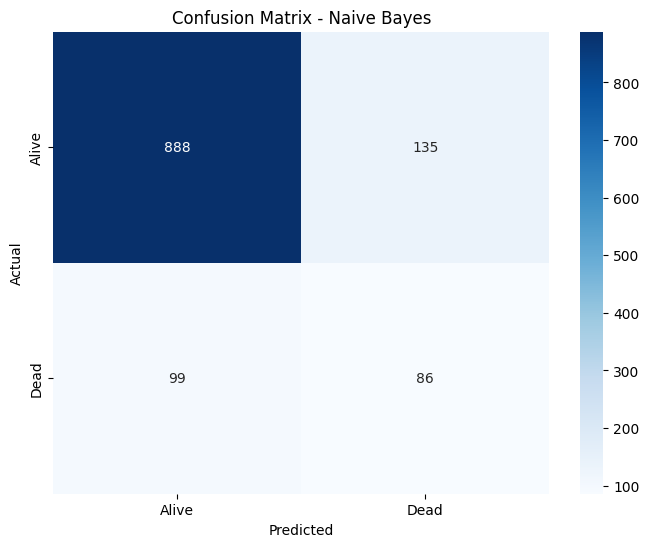

In [9]:
# Cell 6: Comprehensive model evaluation
print("=== MODEL EVALUATION ===")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision']
recall = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall']
f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']

print(f"Naive Bayes Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Alive', 'Dead'], 
            yticklabels=['Alive', 'Dead'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

=== FEATURE IMPORTANCE ANALYSIS ===
Top 10 Most Important Features for Survival Prediction:
Survival Months: 30.4214
Tumor Size: 8.0036
Reginol Node Positive: 3.4854
Age: 1.1826
6th Stage: 0.8845
N Stage: 0.4874
Regional Node Examined: 0.3965
T Stage: 0.3327
Grade: 0.2626
differentiate: 0.2626


/tmp/ipykernel_11559/417849668.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), y='Feature', x='Importance', palette='viridis')


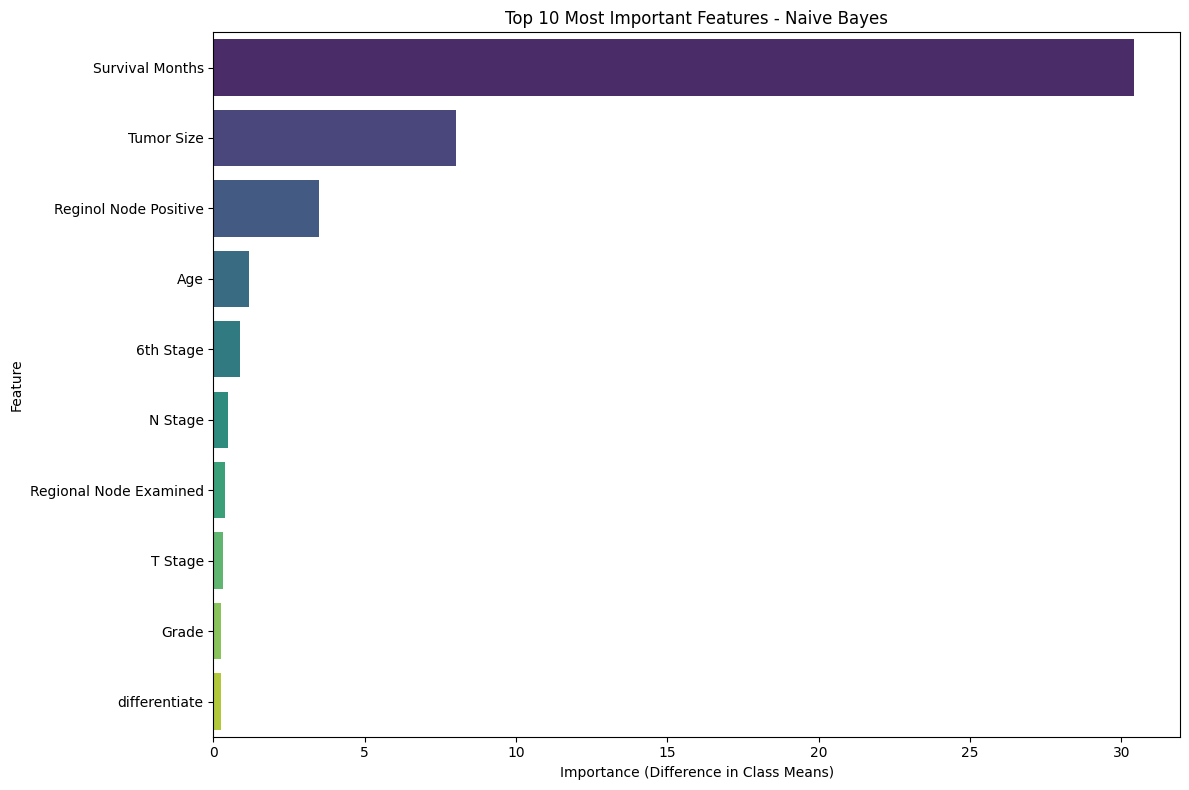

In [10]:
# Cell 7: Feature importance analysis
print("=== FEATURE IMPORTANCE ANALYSIS ===")

# Get feature importance from Naive Bayes
feature_importance = np.abs(naive_bayes_model.theta_[1] - naive_bayes_model.theta_[0])
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features for Survival Prediction:")
for i, row in feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df.head(10), y='Feature', x='Importance', palette='viridis')
plt.title('Top 10 Most Important Features - Naive Bayes')
plt.xlabel('Importance (Difference in Class Means)')
plt.tight_layout()
plt.show()

In [11]:
# Cell 8: Probability analysis and clinical interpretation
print("=== PROBABILITY ANALYSIS ===")

# Analyze prediction probabilities
prob_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability_Alive': y_pred_proba[:, 0],
    'Probability_Dead': y_pred_proba[:, 1]
})

print("Probability distribution for predictions:")
print(f"Average probability for correct predictions: {prob_df[prob_df['Actual'] == prob_df['Predicted']]['Probability_Alive'].mean():.3f}")
print(f"Average probability for wrong predictions: {prob_df[prob_df['Actual'] != prob_df['Predicted']]['Probability_Alive'].mean():.3f}")

# Show some example predictions with probabilities
print("\nExample predictions with probabilities:")
example_predictions = prob_df.head(10).copy()
example_predictions['Actual_Label'] = example_predictions['Actual'].map({0: 'Alive', 1: 'Dead'})
example_predictions['Predicted_Label'] = example_predictions['Predicted'].map({0: 'Alive', 1: 'Dead'})
print(example_predictions[['Actual_Label', 'Predicted_Label', 'Probability_Alive', 'Probability_Dead']])

=== PROBABILITY ANALYSIS ===
Probability distribution for predictions:
Average probability for correct predictions: 0.893
Average probability for wrong predictions: 0.446

Example predictions with probabilities:
     Actual_Label Predicted_Label  Probability_Alive  Probability_Dead
3183        Alive           Alive       9.038306e-01          0.096169
93           Dead            Dead       5.750822e-03          0.994249
1479        Alive            Dead       2.843521e-01          0.715648
1545        Alive           Alive       9.988593e-01          0.001141
2904        Alive           Alive       9.989435e-01          0.001057
21          Alive           Alive       9.819131e-01          0.018087
1219        Alive           Alive       9.887031e-01          0.011297
2288         Dead           Alive       7.438700e-01          0.256130
305          Dead            Dead       4.664090e-09          1.000000
2169        Alive           Alive       9.977806e-01          0.002219


=== COMPARISON WITH BASELINE ===
Naive Bayes Accuracy: 0.8063
Baseline Accuracy (always predict Alive): 0.8469
Improvement over baseline: -0.0406


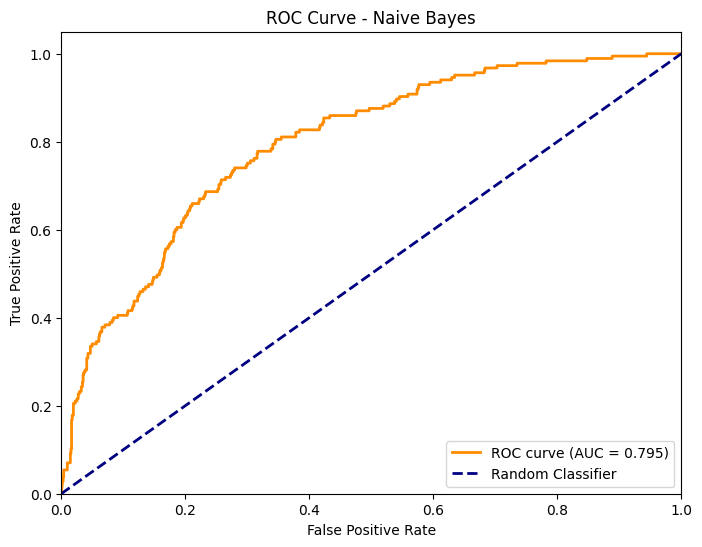

ROC AUC Score: 0.7950


In [12]:
# Cell 9: Compare with simple baseline model
print("=== COMPARISON WITH BASELINE ===")

# Simple baseline: always predict the majority class
baseline_pred = np.zeros_like(y_test)  # Always predict "Alive" (0)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Naive Bayes Accuracy: {accuracy:.4f}")
print(f"Baseline Accuracy (always predict Alive): {baseline_accuracy:.4f}")
print(f"Improvement over baseline: {accuracy - baseline_accuracy:.4f}")

# Calculate additional metrics
from sklearn.metrics import roc_auc_score, roc_curve

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

In [13]:
# Cell 10: Clinical insights and practical application
print("=== CLINICAL INSIGHTS AND PRACTICAL APPLICATION ===")

print("Key Clinical Findings from Naive Bayes Model:")
print("1. Most predictive features for patient survival:")
top_features = feature_importance_df.head(5)
for i, row in top_features.iterrows():
    print(f"   - {row['Feature']} (importance: {row['Importance']:.3f})")

print("\n2. Model Performance Summary:")
print(f"   - Accuracy: {accuracy:.1%} - correctly predicts survival status")
print(f"   - Can identify high-risk patients for closer monitoring")
print(f"   - Provides probability scores for clinical decision support")

print("\n3. How to use this model in practice:")
print("   - Input patient clinical characteristics")
print("   - Get probability of survival")
print("   - High probability of death → more aggressive treatment")
print("   - Low probability of death → standard care")

# Example: Calculate survival probability for a new patient
print("\n4. Example prediction for a new patient:")
example_patient = X_train.iloc[0:1]  # Take first training patient as example
survival_probability = naive_bayes_model.predict_proba(example_patient)[0, 0]
print(f"   Example patient survival probability: {survival_probability:.1%}")

print("\n5. Model Limitations:")
print("   - Assumes all features are independent (Naive assumption)")
print("   - May not capture complex interactions between risk factors")
print("   - Should be used as decision support, not replacement for clinical judgment")

=== CLINICAL INSIGHTS AND PRACTICAL APPLICATION ===
Key Clinical Findings from Naive Bayes Model:
1. Most predictive features for patient survival:
   - Survival Months (importance: 30.421)
   - Tumor Size (importance: 8.004)
   - Reginol Node Positive (importance: 3.485)
   - Age (importance: 1.183)
   - 6th Stage (importance: 0.884)

2. Model Performance Summary:
   - Accuracy: 80.6% - correctly predicts survival status
   - Can identify high-risk patients for closer monitoring
   - Provides probability scores for clinical decision support

3. How to use this model in practice:
   - Input patient clinical characteristics
   - Get probability of survival
   - High probability of death → more aggressive treatment
   - Low probability of death → standard care

4. Example prediction for a new patient:
   Example patient survival probability: 99.8%

5. Model Limitations:
   - Assumes all features are independent (Naive assumption)
   - May not capture complex interactions between risk fac